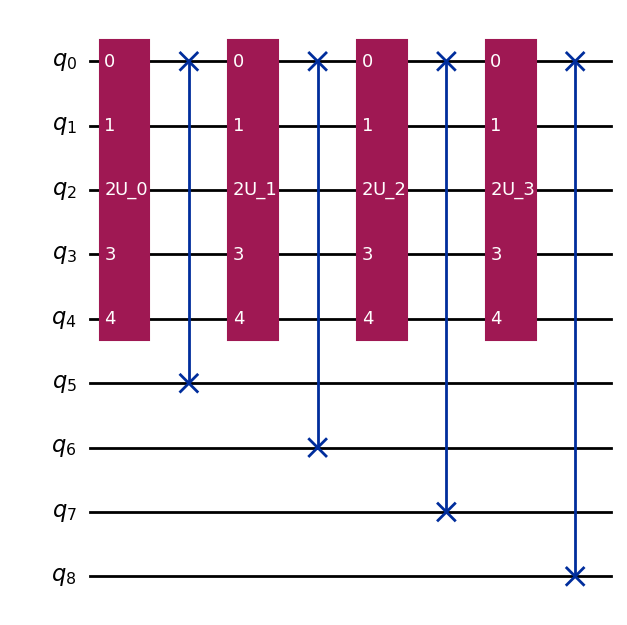

In [4]:
from qiskit import QuantumCircuit, transpile
import sys
import os
import tempfile
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append("../numerical_simulation/")
import utils

from qiskit.qasm2 import dump
from mqt.core import load
from mqt.qmap.hybrid_mapper import (
    NeutralAtomHybridArchitecture,
    HybridNAMapper,
    MapperParameters,
)



# --------------------------------------------------
# Helper: Build circuit for a given iteration count
# --------------------------------------------------
def build_circuit(no_of_iterations):
    dilated_unitary, n_qubits = utils.load_unitary_matrices()
    total_qubits = n_qubits + no_of_iterations

    qc = QuantumCircuit(total_qubits)

    for i in range(no_of_iterations):
        qc.unitary(dilated_unitary[0], range(n_qubits), label=f"U_{i}")
        qc.swap(0, n_qubits + i)
    return qc.draw(output="mpl")

    # basis_gates = ["rx", "rz", "cz", "swap"]
    # return transpile(qc, basis_gates=basis_gates, optimization_level=3)

build_circuit(4)


Running iteration count = 5
Iterations: 5, CZ Gates: 1785.0, Fidelity: 0.9987150821155946
Running iteration count = 10
Iterations: 10, CZ Gates: 3570.0, Fidelity: 0.9986347982558629
Running iteration count = 15
Iterations: 15, CZ Gates: 5355.0, Fidelity: 0.9965176343723832
Running iteration count = 20
Iterations: 20, CZ Gates: 7140.0, Fidelity: 0.9968218630001258
Running iteration count = 25
Iterations: 25, CZ Gates: 8925.0, Fidelity: 0.995941248154551
Running iteration count = 30
Iterations: 30, CZ Gates: 10710.0, Fidelity: 0.9954518243839336
Running iteration count = 35
Iterations: 35, CZ Gates: 12495.0, Fidelity: 0.9935321272771725
Running iteration count = 40
Iterations: 40, CZ Gates: 14280.0, Fidelity: 0.993619973463996
Running iteration count = 45
Iterations: 45, CZ Gates: 16065.0, Fidelity: 0.9914147267337222
Running iteration count = 50
Iterations: 50, CZ Gates: 17850.0, Fidelity: 0.992256216122974
Running iteration count = 55
Iterations: 55, CZ Gates: 19635.0, Fidelity: 0.9903

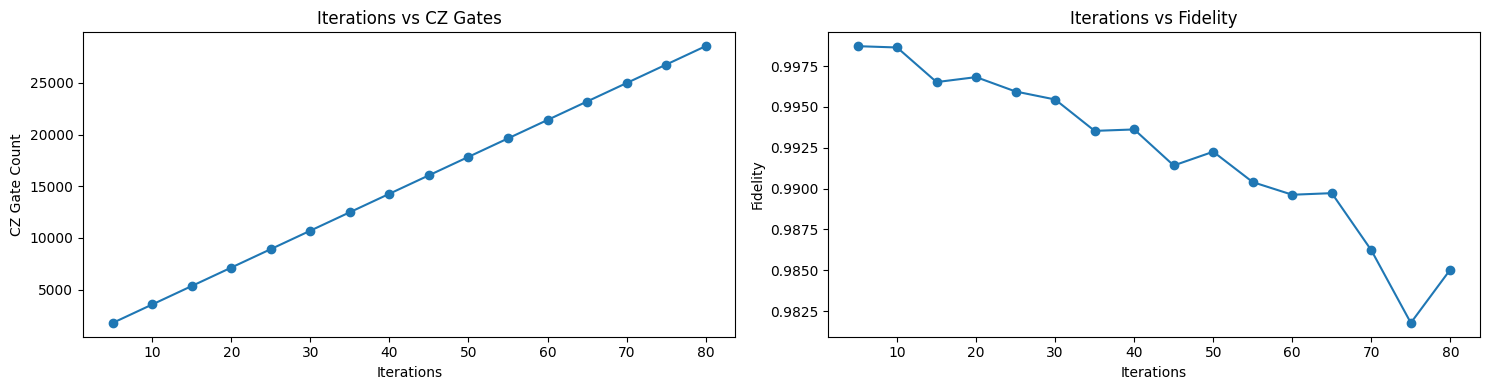

In [2]:
# --------------------------------------------------
# Helper: Save circuit to QASM
# --------------------------------------------------
def save_qiskit_as_qasm(circuit, output_path):
    with open(output_path, "w") as f:
        dump(circuit, f)

# --------------------------------------------------
# Neutral Atom Architecture (unchanged)
# --------------------------------------------------


arch = NeutralAtomHybridArchitecture("./architecture/example.json")


# --------------------------------------------------
# Mapper setup
# --------------------------------------------------
params = MapperParameters()

params1 = {
    "lookahead_weight_swaps": 0.0,
    "lookahead_weight_moves": 0.0,
    "decay": 0.0,
    "shuttling_time_weight": 1.0,
    "gate_weight": 0.0, 
    "shuttling_weight": 1.0,  
}

params.lookahead_weight_swaps = params1["lookahead_weight_swaps"]
params.lookahead_weight_moves = params1["lookahead_weight_moves"]
params.decay = params1["decay"]
params.shuttling_time_weight = params1["shuttling_time_weight"]
params.gate_weight = params1["gate_weight"]
params.shuttling_weight = params1["shuttling_weight"]

mapper = HybridNAMapper(arch, params=params)

# --------------------------------------------------
# Experiment sweep
# --------------------------------------------------
iterations = []
cz_gate_counts = []
fidelities = []

Path("data").mkdir(exist_ok=True)

for it in range(5, 81, 5):
    print(f"Running iteration count = {it}")

    qc = build_circuit(it)
    qasm_path = f"data/tmp_{it}.qasm"
    save_qiskit_as_qasm(qc, qasm_path)

    circ = load(qasm_path)

    mapper.map(circ)
    stats = mapper.get_stats()
    results = mapper.schedule(verbose=False)

    print(
        f"Iterations: {it}, CZ Gates: {results['nCZs']}, Fidelity: {results['totalFidelities']}"
    )

    iterations.append(it)
    cz_gate_counts.append(results["nCZs"])
    fidelities.append(results["totalFidelities"])

# --------------------------------------------------
# Plotting
# --------------------------------------------------
plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
plt.plot(iterations, cz_gate_counts, marker="o")
plt.xlabel("Iterations")
plt.ylabel("CZ Gate Count")
plt.title("Iterations vs CZ Gates")


plt.subplot(1, 2, 2)
plt.plot(iterations, fidelities, marker="o")
plt.xlabel("Iterations")
plt.ylabel("Fidelity")
plt.title("Iterations vs Fidelity")

plt.tight_layout()
plt.show()

Running iteration count = 5
Iterations: 5, Gate Count: 18249, Depth: 11903
Running iteration count = 10
Iterations: 10, Gate Count: 36594, Depth: 23959
Running iteration count = 15
Iterations: 15, Gate Count: 60594, Depth: 42755
Running iteration count = 20
Iterations: 20, Gate Count: 76167, Depth: 51019
Running iteration count = 25
Iterations: 25, Gate Count: 96791, Depth: 65939
Running iteration count = 30
Iterations: 30, Gate Count: 118047, Depth: 82085
Running iteration count = 35
Iterations: 35, Gate Count: 140011, Depth: 98953
Running iteration count = 40
Iterations: 40, Gate Count: 159098, Depth: 111314
Running iteration count = 45
Iterations: 45, Gate Count: 177413, Depth: 123413
Running iteration count = 50
Iterations: 50, Gate Count: 198438, Depth: 139067
Running iteration count = 55
Iterations: 55, Gate Count: 215391, Depth: 148536
Running iteration count = 60
Iterations: 60, Gate Count: 232775, Depth: 158859
Running iteration count = 65
Iterations: 65, Gate Count: 255147, D

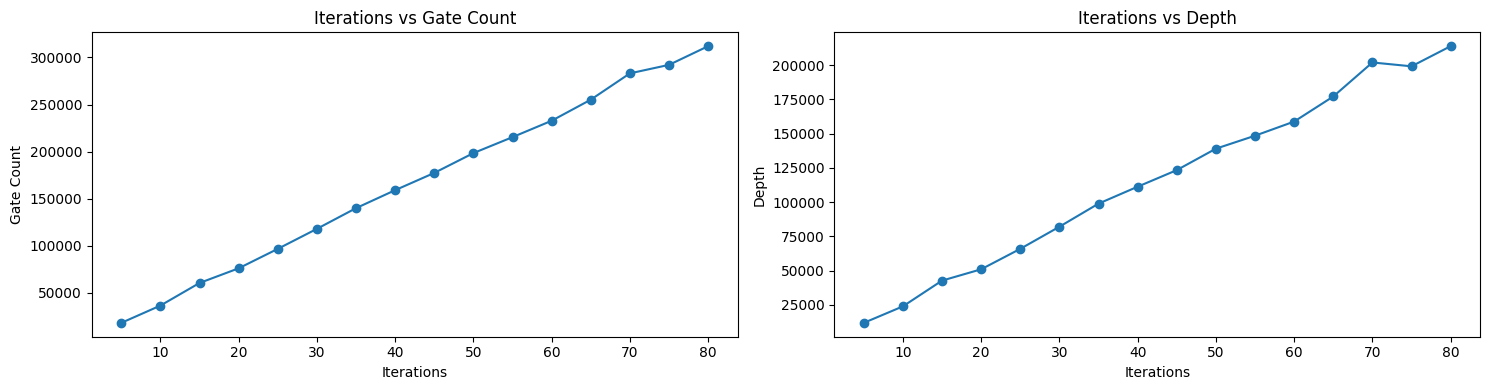

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap
import sys
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append("../numerical_simulation/")
import utils

def build_circuit(no_of_iterations):
    dilated_unitary, n_qubits = utils.load_unitary_matrices()
    total_qubits = n_qubits + no_of_iterations

    ancilla_idx = 0
    qc = QuantumCircuit(total_qubits)

    for i, U_s in enumerate(dilated_unitary):
        qc.unitary(U_s, range(n_qubits), label=f"U_{i}")
        if i % 2 == 1:
            qc.swap(0, n_qubits + ancilla_idx)
            ancilla_idx += 1
        if ancilla_idx == no_of_iterations:
            break

    return qc

coupling_map = CouplingMap.from_grid(10, 10)

basis_gates = ["rx", "rz", "cz", "swap"]

iterations = []
gate_counts = []
depth = []

for it in range(5, 81, 5):
    print(f"Running iteration count = {it}")
    qc = build_circuit(it)

    transpiled_circuit = transpile(qc, coupling_map=coupling_map, basis_gates=basis_gates, optimization_level=1)

    print(
        f"Iterations: {it}, Gate Count: {transpiled_circuit.size()}, Depth: {transpiled_circuit.depth()}"
    )

    iterations.append(it)
    gate_counts.append(transpiled_circuit.size())
    depth.append(transpiled_circuit.depth())

# --------------------------------------------------
# Plotting
# --------------------------------------------------
plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
plt.plot(iterations, gate_counts, marker="o")
plt.xlabel("Iterations")
plt.ylabel("Gate Count")
plt.title("Iterations vs Gate Count")

plt.subplot(1, 2, 2)
plt.plot(iterations, depth, marker="o")
plt.xlabel("Iterations")
plt.ylabel("Depth")
plt.title("Iterations vs Depth")

plt.tight_layout()
plt.show()



